In [9]:
import numpy as np
import pickle
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit, GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from collections import defaultdict

In [ ]:
#Load features
with open("data/features/dataset.pkl", "rb") as f:
    data = pickle.load(f)

X = data["X"]
y = data["y"]

np.random.seed(42)
patient_ids = np.repeat(np.arange(1, 201), len(y) // 200 + 1)[:len(y)]

In [ ]:
#Build patient to indices mapping
patient_to_indices = defaultdict(list)

for idx, pid in enumerate(patient_ids):
    patient_to_indices[pid].append(idx)

# Patient-level labels
patient_labels = []
unique_patients = []

for pid, indices in patient_to_indices.items():
    unique_patients.append(pid)
    patient_labels.append(y[indices[0]]) #all segments share same label

unique_patients = np.array(unique_patients)
patient_labels = np.array(patient_labels)

#Stratified split at patient level
train_pids, test_pids = train_test_split(
    unique_patients,
    test_size=0.2,
    stratify=patient_labels,
    random_state=42
)

#Expand back to segment indices
train_idx = []
test_idx = []

for pid in train_pids:
    train_idx.extend(patient_to_indices[pid])

for pid in test_pids:
    test_idx.extend(patient_to_indices[pid])

train_idx = np.array(train_idx)
test_idx = np.array(test_idx)

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print("Train class counts:", np.unique(y_train, return_counts=True))
print("Test class counts:", np.unique(y_test, return_counts=True))

Train class counts: (array(['copd', 'healthy'], dtype='<U7'), array([1233,   54]))
Test class counts: (array(['copd', 'healthy'], dtype='<U7'), array([301,  17]))


In [ ]:
models = {
    "Logistic Regression": (
        LogisticRegression(max_iter=2000),
        {"clf__C": [0.01, 0.1, 1, 10]}
    ),
    "Random Forest": (
        RandomForestClassifier(random_state=42),
        {
            "clf__n_estimators": [100, 200],
            "clf__max_depth": [None, 10, 20]
        }
    ),
    "SVM": (
        SVC(),
        {
            "clf__C": [0.1, 1, 10],
            "clf__kernel": ["linear", "rbf"]
        }
    ),
    "Neural Network": (
        MLPClassifier(max_iter=500, random_state=42),
        {
            "clf__hidden_layer_sizes": [(64,), (128,), (64, 64)],
            "clf__alpha": [0.0001, 0.001]
        }
    )
}


Training Logistic Regression...


c:\Users\reach\Projects\copd-audio-ml\.venv\Lib\site-packages\sklearn\model_selection\_search.py:1137: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan]
  warnings.warn(


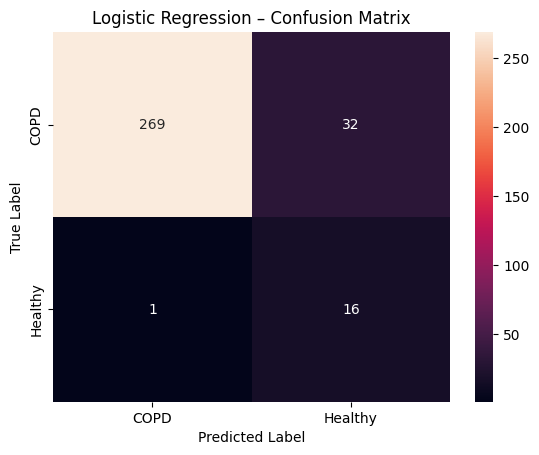


Training Random Forest...


c:\Users\reach\Projects\copd-audio-ml\.venv\Lib\site-packages\sklearn\model_selection\_search.py:1137: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan]
  warnings.warn(


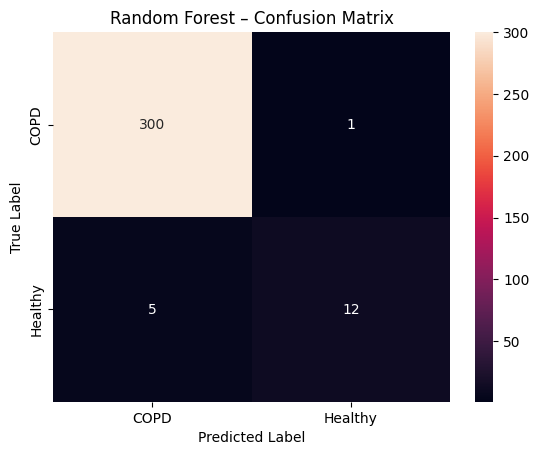


Training SVM...


c:\Users\reach\Projects\copd-audio-ml\.venv\Lib\site-packages\sklearn\model_selection\_search.py:1137: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan]
  warnings.warn(


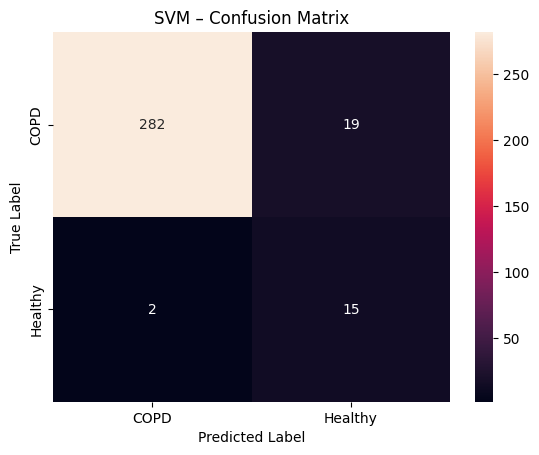


Training Neural Network...


c:\Users\reach\Projects\copd-audio-ml\.venv\Lib\site-packages\sklearn\model_selection\_search.py:1137: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan]
  warnings.warn(


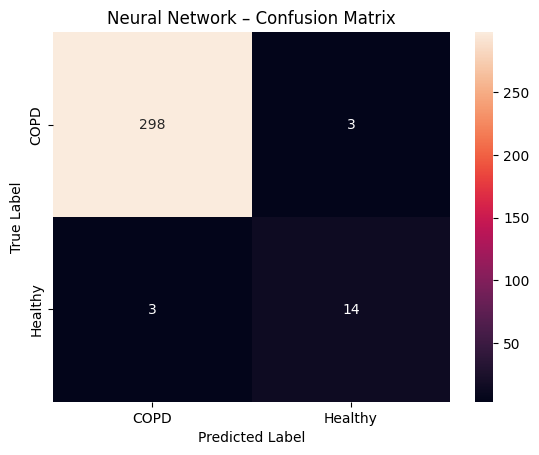


Model Comparison Table:
                 Model  Accuracy  Precision    Recall
0  Logistic Regression  0.896226   0.996296  0.893688
1        Random Forest  0.981132   0.983607  0.996678
2                  SVM  0.933962   0.992958  0.936877
3       Neural Network  0.981132   0.990033  0.990033


In [ ]:
results = []

for model_name, (clf, param_grid) in models.items():

    pipeline = ImbPipeline([
        ("scaler", StandardScaler()),
        ("smote", SMOTE(random_state=42)),
        ("clf", clf)
    ])

    grid = GridSearchCV(
        pipeline,
        param_grid,
        scoring="recall",
        cv=5,
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, pos_label="copd")
    rec = recall_score(y_test, y_pred, pos_label="copd")
    cm = confusion_matrix(y_test, y_pred, labels=["copd", "healthy"])

    results.append({
        "Model": model_name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "Confusion Matrix": cm,
        "Best Params": grid.best_params_
    })

    #Confusion matrix heatmap
    plt.figure()
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=["COPD", "Healthy"],
        yticklabels=["COPD", "Healthy"]
    )
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"{model_name} – Confusion Matrix")
    plt.show()

In [ ]:
#Comparison Table
results_df = pd.DataFrame(results)

print("Model Comparison Table:")
print(results_df[["Model", "Accuracy", "Precision", "Recall"]])